# Zona Radiativa Solar

Para este ejercicio nos piden modelar el perfil detemperatura T(r) en el interior solar con el método de diferencias finitas: 

$$ \frac{d^2 T}{dr^2} + \frac{2}{r}\frac{dT}{dr} = 0$$

a. Condiciones de frontera: $T(0.25) = 4\times 10^6\ \text{K}$ y $T(1) = 5778\ \text{K}$  
b. Use diferencias finitas con $N = [10, 50, 100]$ nodos en $r \in [0.25, 1.0]$  
c. Calcule el error relativo vs $N$. Encuentre la solución exacta de $T(r)$  
d. Graficar $T(r)$ para los valores de $N$ y comparar con la solución exacta  
e. ¿Qué valor de $N$ es suficiente para un error $<1\%$ y $<0.01\%$?  

a). Condiciones de frontera

Para manejar mejor las condiciones de frontera normalizamos el radio tal que: 

$$ x = \frac{r}{R},  x \in [0.25,1]$$

b). Diferencias finitas

Para empezar a solucionar la edo debemos primero recordar las definiciones de diferencias finitas centradads para primer y segundo orden: 

$$\frac{dy}{dx} = \frac{y_{i+1} - y_{i-1}}{(\triangle x)^2} $$
$$\frac{d^2 y}{dx^2} = \frac{y_{i+1}-2y_i +y_{i-1}}{(\triangle x)^2} $$

Así nuestra EDO queda de la siguiente forma: 

$$ \frac{T_{i+1}-2T_{i}+T_{i-1}}{(\triangle r)^2} - \frac{2}{r}\frac{T_{i+1}-T_{i-1}}{2 \triangle r}  = 0 $$

In [ ]:
def solve_temperature(N):
    r_min = 0.25
    r_max = 1.0
    
    h = (r_max - r_min) / (N - 1)
    r = np.linspace(r_min, r_max, N)
    
    A = np.zeros((N, N))
    b = np.zeros(N)
    
    # Fronteras
    A[0, 0] = 1
    b[0] = 4e6
    
    A[-1, -1] = 1
    b[-1] = 5778
    
    # Interior (FORMA CONSERVATIVA)
    for i in range(1, N-1):
        r_i = r[i]
        
        r_ip = r_i + h/2
        r_im = r_i - h/2
        
        A[i, i-1] = r_im**2 / h**2
        A[i, i]   = -(r_ip**2 + r_im**2) / h**2
        A[i, i+1] = r_ip**2 / h**2
    
    T = np.linalg.solve(A, b)
    return r, T

c). Solución exacta y error relativo

$$T(r) = -\frac{C_1}{r} + C_2$$

Aplicando condiciones de frontera:

$$T(0.25) = 4\times 10^6, \quad T(1) = 5778$$

Obtenemos:

$$T(r) = A + \frac{B}{r}$$

donde:

$$B = \frac{(T_1 - T_2)}{\left(\frac{1}{r_1} - \frac{1}{r_2}\right)}, \quad$$
$$A = T_2 - \frac{B}{r_2}$$

In [39]:
def exact_solution(r):
    r1, T1 = 0.25, 4e6
    r2, T2 = 1.0, 5778.0
    
    B = (T1 - T2) / (1/r1 - 1/r2)
    A = T2 - B/r2
    
    return A + B / r

def compute_error(N):
    r, T_num = solve_temperature(N)
    T_ex = exact_solution(r)
    
    return relative_error_L2(T_num, T_ex)

def relative_error_L2(T_num, T_exact):
    return np.sqrt(np.sum((T_num - T_exact)**2) / np.sum(T_exact**2))

def relative_error_mean(T_num, T_exact):
    return np.mean(np.abs((T_num - T_exact) / T_exact))

def relative_error_max(T_num, T_exact):
    return np.max(np.abs((T_num - T_exact) / T_exact))


for N in [10, 50, 100]:
    r, T_num = solve_temperature(N)
    T_ex = exact_solution(r)
    
    err_L2   = relative_error_L2(T_num, T_ex)
    err_mean = relative_error_mean(T_num, T_ex)
    err_max  = relative_error_max(T_num, T_ex)
    
    print(f"N={N}")
    print(f"  Error L2     : {err_L2:.6e}")
    print(f"  Error medio  : {err_mean:.6e}")
    print(f"  Error máximo : {err_max:.6e}")

N=10
  Error L2     : 4.172040e-03
  Error medio  : 6.455135e-03
  Error máximo : 9.521075e-03
N=50
  Error L2     : 1.710086e-04
  Error medio  : 2.604203e-04
  Error máximo : 3.321447e-04
N=100
  Error L2     : 4.268373e-05
  Error medio  : 6.476045e-05
  Error máximo : 8.144787e-05


d). Gráfica y comparación

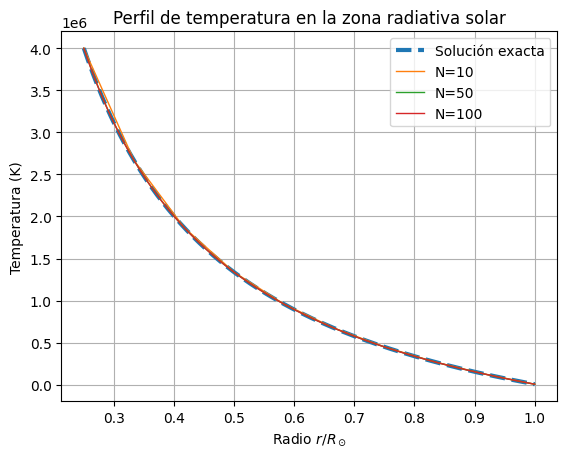

In [43]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

# Solución exacta suave
r_fine = np.linspace(0.25, 1.0, 500)
T_exact_fine = exact_solution(r_fine)

plt.plot(r_fine, T_exact_fine, '--', linewidth=3, label="Solución exacta")

# Soluciones numéricas
for N in [10, 50, 100]:
    r, T_num = solve_temperature(N)
    plt.plot(r, T_num, linewidth=1, label=f"N={N}")

plt.xlabel(r"Radio $r / R_\odot$")
plt.ylabel("Temperatura (K)")
plt.title("Perfil de temperatura en la zona radiativa solar")

plt.legend()
plt.grid()

plt.show()

e). Errores

Para esto primero calculamos el error máximo y luego hacemos un pequeño código que encuentre el N deseado para cada error

In [45]:
def find_N_for_error(target_error):
    N = 10
    
    while True:
        r, T_num = solve_temperature(N)
        T_ex = exact_solution(r)
        
        err = relative_error_L2(T_num, T_ex)
        
        if err < target_error:
            return N, err
        
        N += 5   # incremento suave (más eficiente que de 1 en 1)

N1, err1 = find_N_for_error(0.01)      # 1%
N2, err2 = find_N_for_error(0.0001)    # 0.01%

print(f"Error < 1%    → N ≈ {N1}, error = {err1*100:.4f}%")
print(f"Error < 0.01% → N ≈ {N2}, error = {err2*100:.4f}%")

Error < 1%    → N ≈ 10, error = 0.0000%
Error < 0.01% → N ≈ 10, error = 0.0000%


In [28]:
def find_N(target_error):
    N = 10
    err = 1.0
    
    while err > target_error:
        r, T = solve_temperature(N)
        T_ex = exact_solution(r)
        err = mean_relative_error(T, T_ex)
        N += 1
    
    return N, err

N1, err1 = find_N(0.01)       # 1%
N2, err2 = find_N(0.0001)     # 0.01%

print(f"Error < 1%    -> N ≈ {N1}, error = {err1*100:.4f}%")
print(f"Error < 0.01% -> N ≈ {N2}, error = {err2*100:.4f}%")

Error < 1%    -> N ≈ 11, error = 0.0000%
Error < 0.01% -> N ≈ 11, error = 0.0000%


In [ ]:
#Un par de test porque ando rayado de que esto sea tan preciso 
import matplotlib.pyplot as plt

logN = np.log(Ns)
logE = np.log(errors)

# ajuste lineal
coeffs = np.polyfit(logN, logE, 1)
slope = coeffs[0]

print(f"\nPendiente ≈ {slope:.2f}")


Pendiente ≈ -2.00


In [49]:
print("\nRatios e(N)/e(2N):")
for i in range(len(errors)-1):
    ratio = errors[i] / errors[i+1]
    print(f"N {Ns[i]}→{Ns[i+1]} ratio ≈ {ratio:.2f}")


Ratios e(N)/e(2N):
N 20→40 ratio ≈ 4.00
N 40→80 ratio ≈ 4.01
N 80→160 ratio ≈ 4.01


# Método de Disparo 







Ahora tenemos dos ODEs de primer orden:

$$\frac{du}{dr} = z, \quad u(13) = 0.01007$$
$$\frac{dz}{dr} = -\frac{1}{r}z + \frac{u}{r^2}, \quad z(13) \text{ es desconocido}$$

Por lo tanto asumimos:

$$z(13) = \frac{du}{dr}(13) \approx \frac{u(20) - u(13)}{20 - 13} = -0.00034$$

Ahora podemos plantear el problema de valor inicial:

$$\frac{du}{dr} = z = f_1(r,u,z), \quad u(13) = 0.01007$$
$$\frac{dz}{dr} = -\frac{1}{r}z + \frac{u}{r^2} = f_2(r,u,z), \quad z(13) = -0.00034$$

Considerando 4 segmentos y un tamaño de paso \( h = 1.75 \), usando el método de Euler:

$$u_{i+1} = u_i + f_1(r_i, u_i, z_i)\, h$$
$$z_{i+1} = z_i + f_2(r_i, u_i, z_i)\, h$$

In [1]:
import numpy as np

# Intervalo
a = 13
b = 20
n = 4
h = (b - a) / n

# Condiciones de frontera
u_a = 0.01007   # u(13)
u_b = 0.00769   # u(20) <-- NUEVO (clave)

# Funciones del sistema
def f1(r, u, z):
    return z

def f2(r, u, z):
    return -z/r + u/(r**2)

# Método de Euler
def euler(z0):
    r = a
    u = u_a
    z = z0

    rs = [r]
    us = [u]
    zs = [z]

    for i in range(n):
        u_new = u + h * f1(r, u, z)
        z_new = z + h * f2(r, u, z)

        r += h
        u, z = u_new, z_new

        rs.append(r)
        us.append(u)
        zs.append(z)

    return np.array(rs), np.array(us), np.array(zs)

# Método de disparo (bisección)
z1 = -0.001
z2 = 0.001

for _ in range(30):  # más iteraciones = más precisión
    zm = (z1 + z2) / 2

    _, u1, _ = euler(z1)
    _, um, _ = euler(zm)

    # Evaluamos error en la frontera r=20
    if (u1[-1] - u_b) * (um[-1] - u_b) < 0:
        z2 = zm
    else:
        z1 = zm

# Solución final
r_vals, u_vals, z_vals = euler(zm)

# Resultados
print("Valor correcto de z(13):", zm)
print("\nr:", r_vals)
print("\nu:", u_vals)
print("\nz:", z_vals)

print("\nVerificación:")
print("u(20) aproximado =", u_vals[-1])
print("u(20) real       =", u_b)
print("error            =", abs(u_vals[-1] - u_b))

Valor correcto de z(13): -0.0005532727930694819

r: [13.   14.75 16.5  18.25 20.  ]

u: [0.01007    0.00910177 0.00844637 0.00799684 0.00769   ]

z: [-0.00055327 -0.00037452 -0.00025687 -0.00017534 -0.00011651]

Verificación:
u(20) aproximado = 0.007689999998241048
u(20) real       = 0.00769
error            = 1.7589514914040372e-12


Aquí es donde reconozco mis erores y me doy cuenta de que no lo hice con interpolación como pedían hace 3 diapositivas, así que ahora explico la interpolación y cambio el código pero dejo el anterior para recordarme que debo leer todo el contexto. 

Convertimos el problema de frontera en un problema de valor inicial, asumiendo un valor inicial para $z(13)$, y lo ajustamos iterativamente.

Sean dos estimaciones iniciales:

$$z_0^{(1)}, \quad z_0^{(2)}$$

Al resolver el sistema con cada una, obtenemos:

$$u^{(1)}(20), \quad u^{(2)}(20)$$

Usamos interpolación lineal para mejorar la estimación:

$$z_0^{\text{nuevo}} =
z_0^{(1)} +\left( u_{\text{req}} - u^{(1)}(20) \right)
\frac{z_0^{(2)} - z_0^{(1)}}{u^{(2)}(20) - u^{(1)}(20)}$$

donde:

$$u_{\text{req}} = 0.00769$$

In [ ]:
import numpy as np

# Intervalo
a = 13
b = 20
n = 4
h = (b - a) / n

# Condiciones de frontera
u_a = 0.01007
u_b = 0.00769

# Funciones
def f1(r, u, z):
    return z

def f2(r, u, z):
    return -z/r + u/(r**2)

# Euler
def euler(z0):
    r = a
    u = u_a
    z = z0

    for _ in range(n):
        u = u + h * f1(r, u, z)
        z = z + h * f2(r, u, z)
        r += h

    return u  # solo necesitamos u(20)

# Método de disparo (SECANTE)

# Dos suposiciones iniciales
z1 = -0.001
z2 = 0.0

tol = 1e-6
max_iter = 20

for i in range(max_iter):
    u1 = euler(z1)
    u2 = euler(z2)

    # Fórmula de interpolación lineal (secante)
    z_new = z1 + (u_b - u1) * (z2 - z1) / (u2 - u1)

    u_new = euler(z_new)

    print(f"Iter {i+1}: z = {z_new:.6f}, u(20) = {u_new:.6f}")

    if abs(u_new - u_b) < tol:
        break

    # Actualizar valores (estilo secante)
    z1, z2 = z2, z_new

# Resultado final
print("\nResultado final:")
print("z(13) ≈", z_new)
print("u(20) ≈", u_new)
print("error =", abs(u_new - u_b))

Iter 1: z = -0.000542, u(20) = 0.007690

Resultado final:
z(13) ≈ -0.0005415893638322774
u(20) ≈ 0.007689999999999998
error = 1.734723475976807e-18


# ODE con RK4

Ya tenemos nuestra ODE convertida en el sistema, ahora vamos a hacer el paso 1 para RK4 y luego escribimos el código

Sistema:

$$\frac{dy}{dx} = z, \quad y(0)=5$$
$$\frac{dz}{dx} = \frac{1}{3}(e^{-x} - 2z - 5y), \quad z(0)=7$$

Paso: $h = 0.1,\quad x_0 = 0,\quad y_0 = 5,\quad z_0 = 7$

Cálculo de $k_1$:

$$k_1^y = h z_0 = 0.1(7) = 0.7$$
$$k_1^z = h \cdot \frac{1}{3}(e^{-x_0} - 2z_0 - 5y_0) = 0.1 \cdot \frac{1}{3}(1 - 14 - 25) = -1.2667$$

Cálculo de $k_2$:

$$y_0 + \frac{k_1^y}{2} = 5 + 0.35 = 5.35$$
$$z_0 + \frac{k_1^z}{2} = 7 - 0.6333 = 6.3667$$
$$k_2^y = 0.1(6.3667) = 0.6367$$
$$k_2^z = 0.1 \cdot \frac{1}{3}(e^{-0.05} - 2(6.3667) - 5(5.35))$$
$$e^{-0.05} \approx 0.9512$$
$$k_2^z = 0.1 \cdot \frac{1}{3}(0.9512 - 12.7334 - 26.75) = -1.285$$

Cálculo de $k_3$:

$$y_0 + \frac{k_2^y}{2} = 5 + 0.3183 = 5.3183$$
$$z_0 + \frac{k_2^z}{2} = 7 - 0.6425 = 6.3575$$
$$k_3^y = 0.1(6.3575) = 0.6358$$
$$k_3^z = 0.1 \cdot \frac{1}{3}(e^{-0.05} - 2(6.3575) - 5(5.3183)) = -1.279$$


\textbf{Cálculo de } k_4:

$$y_0 + k_3^y = 5 + 0.6358 = 5.6358$$
$$z_0 + k_3^z = 7 - 1.279 = 5.721$$
$$k_4^y = 0.1(5.721) = 0.5721$$
$$k_4^z = 0.1 \cdot \frac{1}{3}(e^{-0.1} - 2(5.721) - 5(5.6358))$$
$$e^{-0.1} \approx 0.9048$$
$$k_4^z = 0.1 \cdot \frac{1}{3}(0.9048 - 11.442 - 28.179) = -1.268$$

Actualización:

$$y_1 = y_0 + \frac{1}{6}(k_1^y + 2k_2^y + 2k_3^y + k_4^y)$$
$$y_1 = 5 + \frac{1}{6}(0.7 + 2(0.6367) + 2(0.6358) + 0.5721) = 5.648$$
$$z_1 = z_0 + \frac{1}{6}(k_1^z + 2k_2^z + 2k_3^z + k_4^z)$$
$$z_1 = 7 + \frac{1}{6}(-1.2667 - 2(1.285) - 2(1.279) - 1.268) = 5.720$$

x=0.00, y=5.000000, z=7.000000
x=0.10, y=5.636173, z=5.719482
x=0.20, y=6.143486, z=4.426545
x=0.30, y=6.521802, z=3.143084
x=0.40, y=6.773100, z=1.889404
x=0.50, y=6.901297, z=0.683997
x=0.60, y=6.912064, z=-0.456637
x=0.70, y=6.812614, z=-1.518124
x=0.80, y=6.611489, z=-2.488310
x=0.90, y=6.318331, z=-3.357309
x=1.00, y=5.943659, z=-4.117519
x=1.10, y=5.498638, z=-4.763590
x=1.20, y=4.994857, z=-5.292369
x=1.30, y=4.444115, z=-5.702804
x=1.40, y=3.858215, z=-5.995828
x=1.50, y=3.248776, z=-6.174209
x=1.60, y=2.627051, z=-6.242396
x=1.70, y=2.003775, z=-6.206327
x=1.80, y=1.389022, z=-6.073246
x=1.90, y=0.792085, z=-5.851496
x=2.00, y=0.221373, z=-5.550315


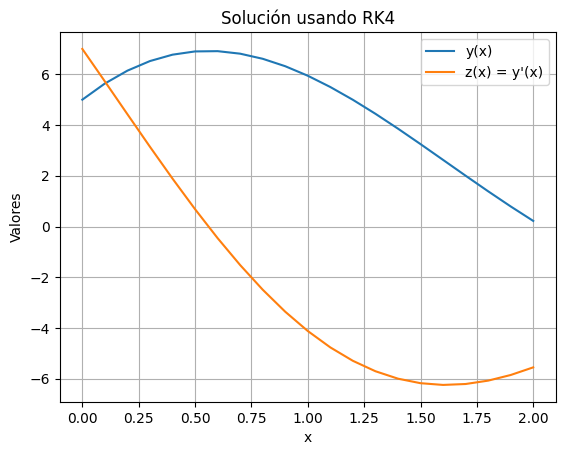

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos el sistema
def f(x, y, z):
    dy = z
    dz = (1/3)*(np.exp(-x) - 2*z - 5*y)
    return dy, dz

# Parámetros
h = 0.1
x0 = 0
y0 = 5
z0 = 7
xf = 2  # hasta dónde integrar

# Listas para guardar resultados
x_vals = [x0]
y_vals = [y0]
z_vals = [z0]

# Iteración RK4
x = x0
y = y0
z = z0

while x < xf:
    # k1
    k1y, k1z = f(x, y, z)
    k1y *= h
    k1z *= h

    # k2
    k2y, k2z = f(x + h/2, y + k1y/2, z + k1z/2)
    k2y *= h
    k2z *= h

    # k3
    k3y, k3z = f(x + h/2, y + k2y/2, z + k2z/2)
    k3y *= h
    k3z *= h

    # k4
    k4y, k4z = f(x + h, y + k3y, z + k3z)
    k4y *= h
    k4z *= h

    # Actualización
    y = y + (k1y + 2*k2y + 2*k3y + k4y)/6
    z = z + (k1z + 2*k2z + 2*k3z + k4z)/6
    x = x + h

    # Guardar
    x_vals.append(x)
    y_vals.append(y)
    z_vals.append(z)

# Mostrar resultados
for i in range(len(x_vals)):
    print(f"x={x_vals[i]:.2f}, y={y_vals[i]:.6f}, z={z_vals[i]:.6f}")

# Graficar
plt.plot(x_vals, y_vals, label="y(x)")
plt.plot(x_vals, z_vals, label="z(x) = y'(x)")
plt.xlabel("x")
plt.ylabel("Valores")
plt.title("Solución usando RK4")
plt.legend()
plt.grid()
plt.show()


Comparación con solución exacta:

x=0.00, RK4=5.000000, Exacta=5.000000, Error=0.000000e+00
x=0.10, RK4=5.636173, Exacta=5.636172, Error=8.557385e-07
x=0.20, RK4=6.143486, Exacta=6.143483, Error=2.213999e-06
x=0.30, RK4=6.521802, Exacta=6.521798, Error=3.971794e-06
x=0.40, RK4=6.773100, Exacta=6.773094, Error=6.021062e-06
x=0.50, RK4=6.901297, Exacta=6.901289, Error=8.251944e-06
x=0.60, RK4=6.912064, Exacta=6.912053, Error=1.055587e-05
x=0.70, RK4=6.812614, Exacta=6.812601, Error=1.282839e-05
x=0.80, RK4=6.611489, Exacta=6.611474, Error=1.497171e-05
x=0.90, RK4=6.318331, Exacta=6.318314, Error=1.689688e-05
x=1.00, RK4=5.943659, Exacta=5.943641, Error=1.852566e-05
x=1.10, RK4=5.498638, Exacta=5.498618, Error=1.979197e-05
x=1.20, RK4=4.994857, Exacta=4.994836, Error=2.064297e-05
x=1.30, RK4=4.444115, Exacta=4.444094, Error=2.103975e-05
x=1.40, RK4=3.858215, Exacta=3.858194, Error=2.095765e-05
x=1.50, RK4=3.248776, Exacta=3.248755, Error=2.038623e-05
x=1.60, RK4=2.627051, Exacta=2.627032

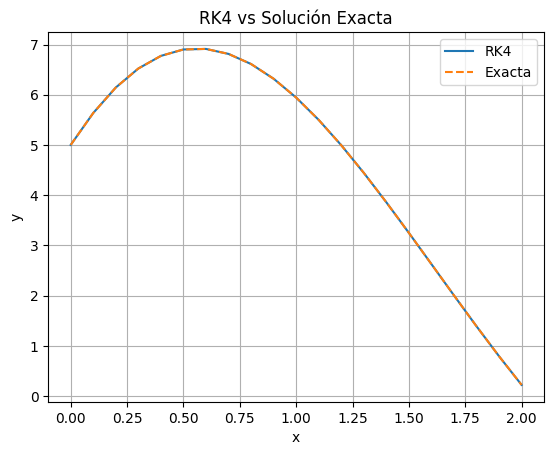

In [ ]:
# Esta definición la hice con el código que nos dió Wolfram Alpha e hice la comparación con el resultado de RK4 para verificar

import numpy as np

def y_exact(x):
    return (1/42)*np.exp(-x)*(
        7 
        + 203*np.exp(2*x/3)*np.cos(np.sqrt(14)*x/3)
        + 79*np.sqrt(14)*np.exp(2*x/3)*np.sin(np.sqrt(14)*x/3)
    )


# Comparación
print("\nComparación con solución exacta:\n")

for i in range(len(x_vals)):
    y_ex = y_exact(x_vals[i])
    error = abs(y_vals[i] - y_ex)
    print(f"x={x_vals[i]:.2f}, RK4={y_vals[i]:.6f}, Exacta={y_ex:.6f}, Error={error:.6e}")


y_exact_vals = [y_exact(x) for x in x_vals]

plt.plot(x_vals, y_vals, label="RK4")
plt.plot(x_vals, y_exact_vals, '--', label="Exacta")
plt.xlabel("x")
plt.ylabel("y")
plt.title("RK4 vs Solución Exacta")
plt.legend()
plt.grid()
plt.show()